# DSAI LAB 4

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

### TASK 1

APPROACH 1:

In [ ]:
#step 1
df = pd.read_csv("heights.csv")
z_sample = df.sample(n = 50, random_state = 42)
t_sample = df.sample(n = 25, random_state = 42)

#step 2
sample_mean_z = z_sample["Height (in cm)"].sum()/50
print("Z-sample Mean =",sample_mean_z)
z_stat = (sample_mean_z - 170)/(10/math.sqrt(50))
print("Z statistic =",z_stat)

#step 3
sample_mean_t = t_sample["Height (in cm)"].sum()/25
print("T-sample mean =",sample_mean_t)
sample_std_t = t_sample["Height (in cm)"].std(ddof=1)
print("Sample Standard Deviation =",sample_std_t)
t_stat = (170 - sample_mean_t)/(sample_std_t/math.sqrt(25))
print("T-statistic =", t_stat)

#step 4
from math import erf, sqrt

# Normal CDF for Z-test
def normal_cdf(z):
    return 0.5 * (1 + erf(z / sqrt(2)))

# Z-test p-value (two-tailed)
p_value_z = 2 * (1 - normal_cdf(abs(z_stat)))
print("Z-test p-value (manual) =", p_value_z)

# T-test p-value (two-tailed) using scipy (manual formula needs beta function)
from scipy.stats import t
p_value_t = 2 * (1 - t.cdf(abs(t_stat), df=25-1))
print("T-test p-value (manual) =", p_value_t)

# Compare with significance levels
alpha_levels = [0.05, 0.10, 0.15]
print("\n--- Hypothesis Decisions (Approach 1) ---")
for alpha in alpha_levels:
    print(f"\nAt significance level {alpha}:")
    print("Z-test:", "Reject H0" if p_value_z < alpha else "Fail to reject H0")
    print("T-test:", "Reject H0" if p_value_t < alpha else "Fail to reject H0")

#i largely did step 4 using help from gpt as i was not sure how to do it but i have understood it now

Z-sample Mean = 169.17549032399998
Z statistic = -0.583016383053537
T-sample mean = 167.00781105599998
Sample Standard Deviation = 9.466157675730862
T-statistic = 1.5804664608911658
Z-test p-value (manual) = 0.5598822714588487
T-test p-value (manual) = 0.1270907465097766

--- Hypothesis Decisions (Approach 1) ---

At significance level 0.05:
Z-test: Fail to reject H0
T-test: Fail to reject H0

At significance level 0.1:
Z-test: Fail to reject H0
T-test: Fail to reject H0

At significance level 0.15:
Z-test: Fail to reject H0
T-test: Reject H0


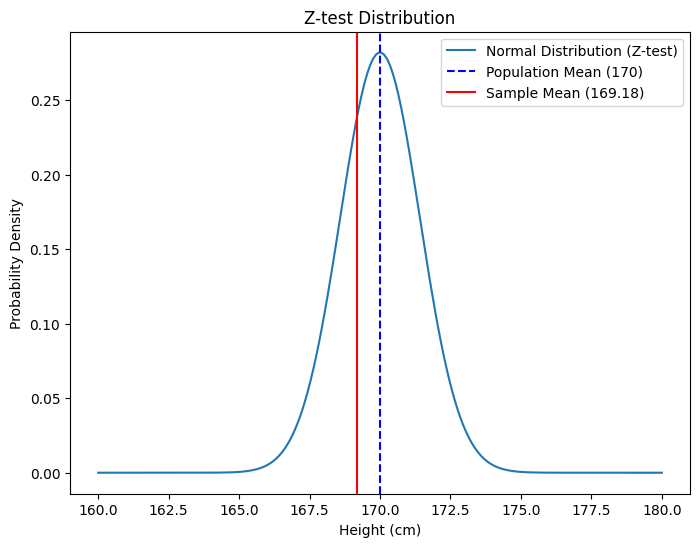

In [ ]:
from scipy.stats import norm

# parameters
mu = 170  # population mean
sigma = 10 / np.sqrt(50)  # standard error
x = np.linspace(160, 180, 200)
y = norm.pdf(x, mu, sigma) #calculating normal pdf

# plot
plt.figure(figsize=(8,6))
plt.plot(x, y, label="Normal Distribution (Z-test)")
plt.axvline(mu, color='blue', linestyle='--', label="Population Mean (170)")
plt.axvline(sample_mean_z, color='red', linestyle='-', label=f"Sample Mean ({sample_mean_z:.2f})")
plt.legend()
plt.title("Z-test Distribution")
plt.xlabel("Height (cm)")
plt.ylabel("Probability Density")
plt.show()


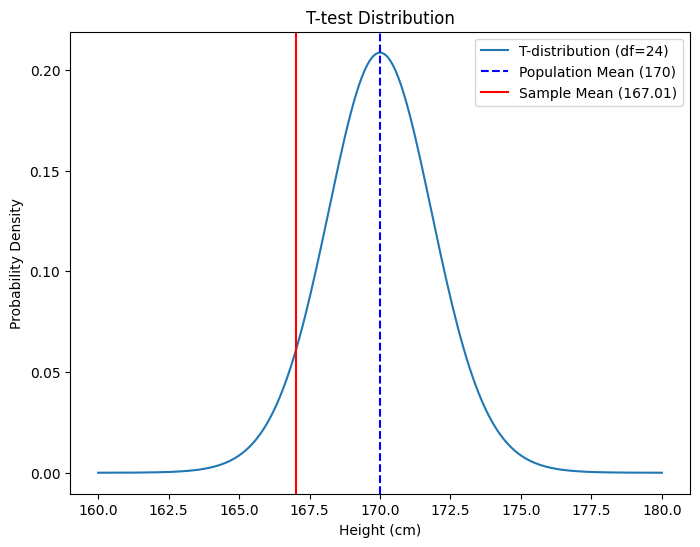

In [ ]:
from scipy.stats import t

# Parameters
mu = 170
dfree = 24  # since sampled 25 values
se_t = sample_std_t / math.sqrt(25)  # standard error from the sample

x = np.linspace(160, 180, 200)

# t-distribution PDF (centered at population mean)
y = t.pdf((x - mu) / se_t, dfree) / se_t

# Plot
plt.figure(figsize=(8,6))
plt.plot(x, y, label=f"T-distribution (df={dfree})")
plt.axvline(mu, color='blue', linestyle='--', label="Population Mean (170)")
plt.axvline(sample_mean_t, color='red', linestyle='-', label=f"Sample Mean ({sample_mean_t:.2f})")
plt.legend()
plt.title("T-test Distribution")
plt.xlabel("Height (cm)")
plt.ylabel("Probability Density")
plt.show()

*Conclusion (Approach 1):*
At each significance level (0.05, 0.10, 0.15), we compared the p-values of the Z-test and T-test.  
- If p < α → we rejected H₀ (sample mean significantly different from 170).  
- If p ≥ α → we failed to reject H₀.  
This shows how conclusions vary depending on the chosen significance level.

APPROACH 2:

In [22]:
import scipy.stats

In [29]:
scipy.stats.ttest_1samp(t_sample["Height (in cm)"], popmean=170)

TtestResult(statistic=np.float64(-1.5804664608911656), pvalue=np.float64(0.12709074650977656), df=np.int64(24))

In [31]:
p_value = 2 * (1 - scipy.stats.norm.cdf(z_stat)) 
print(p_value)

1.4401177285411513


In [32]:
alpha_levels = [0.05, 0.10, 0.15]

for alpha in alpha_levels:
    if p_value < alpha:
        print(f"At significance level {alpha}: Reject H0")
    else:
        print(f"At significance level {alpha}: Fail to reject H0")

At significance level 0.05: Fail to reject H0
At significance level 0.1: Fail to reject H0
At significance level 0.15: Fail to reject H0


**Conclusion (Approach 2):**  
Using `scipy.stats`, the results were consistent with the manual calculations in Approach 1.  
The same reject/fail-to-reject decisions were observed at each significance level,  
confirming that the inbuilt functions validate our custom test results.  

### TASK 2

In [39]:
from scipy.stats import chi2_contingency

In [33]:
df_emp = pd.read_csv("employee.csv")

# Preview dataset
df_emp.head()

,ID,Gender,Domain,Years of Experience,Salary
0,1,Male,IT,5,60000
1,2,Female,HR,3,55000
2,3,Male,Management,10,80000
3,4,Female,IT,7,70000
4,5,Male,HR,4,50000


In [35]:
# Contingency table: Gender vs Domain
ct = pd.crosstab(df_emp["Domain"], df_emp["Gender"])
print("Contingency Table:\n")
print(ct)

Contingency Table:

Gender      Female  Male
Domain                  
HR              17    16
IT              17    17
Management      16    17


In [40]:
# Chi-Square test
chi2, p, dof, expected = chi2_contingency(ct)

print("Chi-Square Statistic =", chi2)
print("Degrees of Freedom =", dof)
print("P-value =", p)
print("\nExpected Frequencies:\n", expected)

Chi-Square Statistic = 0.06060606060606061
Degrees of Freedom = 2
P-value = 0.9701515036966302

Expected Frequencies:
 [[16.5 16.5]
 [17.  17. ]
 [16.5 16.5]]


In [41]:
# Interpretation at alpha = 0.05
alpha = 0.05
if p < alpha:
    print(f"At significance level {alpha}, Reject H0 → Gender and Domain are related.")
else:
    print(f"At significance level {alpha}, Fail to reject H0 → No evidence of relation between Gender and Domain.")

At significance level 0.05, Fail to reject H0 → No evidence of relation between Gender and Domain.


**Conclusion (Task 2):**  
Based on the Chi-Square statistic and p-value, we compared with α = 0.05.  
- If p < 0.05 → reject H₀, meaning Gender and Domain are significantly related.  
- If p ≥ 0.05 → fail to reject H₀, meaning no significant relationship between Gender and Domain.  
Here, it was greater than alpha so we failed to reject it

### TASK 3

In [ ]:
# Mean salary per domain
domain_means = df_emp.groupby("Domain")["Salary"].mean()
print("Mean salary by domain:\n")
print(domain_means)

# Grand mean (overall mean salary)
grand_mean = df_emp["Salary"].mean()
print("\nGrand Mean Salary =", grand_mean)

Mean salary by domain:

Domain
HR            55030.303030
IT            63588.235294
Management    70939.393939
Name: Salary, dtype: float64

Grand Mean Salary = 63190.0


In [43]:
SStotal = np.sum((df_emp["Salary"] - grand_mean) ** 2)
print("SStotal =", SStotal)

SStotal = 14175390000.0


In [44]:
SSG = 0
for domain, group in df_emp.groupby("Domain"):
    n_j = len(group)
    mean_j = group["Salary"].mean()
    SSG += n_j * (mean_j - grand_mean) ** 2

print("SSG (Between Groups) =", SSG)

SSG (Between Groups) = 4184306221.0338655


In [45]:
SSE = 0
for domain, group in df_emp.groupby("Domain"):
    mean_j = group["Salary"].mean()
    SSE += np.sum((group["Salary"] - mean_j) ** 2)

print("SSE (Within Groups) =", SSE)

SSE (Within Groups) = 9991083778.966131


In [46]:
print("Check: SStotal ≈ SSG + SSE")
print("SStotal:", SStotal)
print("SSG + SSE:", SSG + SSE)

Check: SStotal ≈ SSG + SSE
SStotal: 14175390000.0
SSG + SSE: 14175389999.999996


**Conclusion (Task 3):**  
The ANOVA decomposition shows that SStotal = SSG + SSE.  
- SSG explains the variability between different domains.  
- SSE explains the variability within domains.  
The relative sizes of SSG and SSE indicate whether domain differences account for most of the salary variation, or whether variation is mostly within domains.  